# VQA CLIP v2 - Advanced Training

Notebook này thực hiện training nâng cấp cho mô hình Visual Question Answering với các cải tiến:

## 🚀 **Các Cải Tiến Chính:**

1. **Data Augmentation**: Áp dụng các kỹ thuật tăng cường dữ liệu cho hình ảnh để cải thiện khả năng khái quát hóa của mô hình.
2. **Fine-Tuning CLIP**: "Mở băng" (unfreeze) một vài lớp cuối của mô hình CLIP để chúng có thể học các đặc trưng phù hợp hơn với tác vụ VQA.
3. **Learning Rate Phân biệt**: Sử dụng learning rate nhỏ hơn cho các lớp của CLIP và learning rate lớn hơn cho các lớp đầu (head) của mô hình.
4. **Cosine Annealing Scheduler**: Tự động điều chỉnh learning rate theo một đường cong cosine để giúp mô hình hội tụ tốt hơn.
5. **Gradient Clipping**: Ngăn chặn hiện tượng "bùng nổ gradient" (exploding gradients) để quá trình huấn luyện ổn định hơn.
6. **Early Stopping**: Tự động dừng quá trình huấn luyện nếu hiệu suất trên tập validation không còn cải thiện, giúp tiết kiệm thời gian và tránh overfitting.

## 🎯 **Mục Tiêu:**
Huấn luyện mô hình trong 30 epochs, đánh giá trên tập test và trực quan hóa kết quả để đạt được hiệu suất tốt hơn so với phiên bản trước.

## 1. Import Libraries và Setup

In [1]:
# Import required libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR, ReduceLROnPlateau
from transformers import CLIPProcessor
import numpy as np
import matplotlib.pyplot as plt
import os
import time
import warnings
warnings.filterwarnings('ignore')

# Import custom modules
from dataset import create_dataloaders_v2, get_data_transforms
from model import AdvancedCLIPVQAModel, get_model_parameters, FocalLoss
from training_utils import (
    train_model_v2, evaluate_model_v2, EarlyStopping, 
    LearningRateScheduler, plot_training_history, load_checkpoint
)
from visualization import (
    demo_model_predictions, analyze_predictions_v2, 
    create_sample_demo_urls, visualize_attention_v2
)

print("✅ All libraries imported successfully!")
print(f"🔥 PyTorch version: {torch.__version__}")
print(f"🎮 CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"📱 GPU: {torch.cuda.get_device_name(0)}")
    print(f"💾 GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

✅ All libraries imported successfully!
🔥 PyTorch version: 2.7.1+cu126
🎮 CUDA available: True
📱 GPU: Quadro P1000
💾 GPU Memory: 4.0 GB


## 2. Configuration và Hyperparameters

In [2]:
# =====================
# CONFIGURATION
# =====================

# Paths
DATA_DIR = "../data"  # Đường dẫn tới thư mục data
CHECKPOINT_DIR = "../checkpoints"  
RESULTS_DIR = "../results/clip_v2_experiments"

# Create directories
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# =====================
# HYPERPARAMETERS
# =====================

# Model config
CLIP_MODEL_NAME = "openai/clip-vit-base-patch32"
MAX_ANSWERS = 1000  # Top-K most frequent answers
UNFREEZE_LAYERS = 2  # Number of CLIP layers to fine-tune
DROPOUT_RATE = 0.3

# Training config
BATCH_SIZE = 24  # Reduced for memory efficiency
NUM_EPOCHS = 30
NUM_WORKERS = 4

# Learning rates
LEARNING_RATE_HEAD = 1e-4    # For new layers (classifier, fusion, etc.)
LEARNING_RATE_CLIP = 2e-6    # For fine-tuned CLIP layers
WEIGHT_DECAY = 1e-5

# Training techniques
GRADIENT_CLIP_NORM = 1.0
EARLY_STOPPING_PATIENCE = 8
MIN_DELTA = 0.001

# Label Smoothing - NEW ADDITION!
USE_LABEL_SMOOTHING = True
LABEL_SMOOTHING = 0.1  # Smoothing factor for better generalization

# Overfitting Monitoring - NEW ADDITION!
OVERFITTING_THRESHOLD = 10.0  # Train-val gap threshold (%)
MONITOR_INTERVAL = 3  # Check overfitting every N epochs

# Scheduler config
SCHEDULER_TYPE = 'cosine'  # 'cosine', 'cosine_warm', 'reduce_plateau'
ETA_MIN = 1e-7  # Minimum LR for cosine annealing

# Loss function
USE_FOCAL_LOSS = False  # Set True để sử dụng Focal Loss cho class imbalance
FOCAL_ALPHA = 1.0
FOCAL_GAMMA = 2.0

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("⚙️ Configuration:")
print(f"  🎯 Device: {device}")
print(f"  📊 Batch size: {BATCH_SIZE}")
print(f"  🔄 Epochs: {NUM_EPOCHS}")
print(f"  📚 Max answers: {MAX_ANSWERS}")
print(f"  🔓 Unfreeze layers: {UNFREEZE_LAYERS}")
print(f"  🎓 Head LR: {LEARNING_RATE_HEAD}")
print(f"  🔒 CLIP LR: {LEARNING_RATE_CLIP}")
print(f"  ⏰ Early stopping patience: {EARLY_STOPPING_PATIENCE}")
print(f"  ✂️ Gradient clipping: {GRADIENT_CLIP_NORM}")
print(f"  🎭 Label smoothing: {LABEL_SMOOTHING if USE_LABEL_SMOOTHING else 'Disabled'}")
print(f"  📈 Overfitting monitoring: Every {MONITOR_INTERVAL} epochs (threshold: {OVERFITTING_THRESHOLD}%)")

⚙️ Configuration:
  🎯 Device: cuda
  📊 Batch size: 24
  🔄 Epochs: 30
  📚 Max answers: 1000
  🔓 Unfreeze layers: 2
  🎓 Head LR: 0.0001
  🔒 CLIP LR: 2e-06
  ⏰ Early stopping patience: 8
  ✂️ Gradient clipping: 1.0
  🎭 Label smoothing: 0.1
  📈 Overfitting monitoring: Every 3 epochs (threshold: 10.0%)


## 3. Data Loading với Augmentation

In [3]:
# Load CLIP processor
print("🔄 Loading CLIP processor...")
processor = CLIPProcessor.from_pretrained(CLIP_MODEL_NAME)
print("✅ CLIP processor loaded!")

# Create data loaders with augmentation
print("\n🔄 Creating data loaders with augmentation...")

try:
    train_loader, val_loader, test_loader, num_classes = create_dataloaders_v2(
        data_dir=DATA_DIR,
        processor=processor,
        batch_size=BATCH_SIZE,
        max_answers=MAX_ANSWERS,
        num_workers=NUM_WORKERS
    )
    
    print(f"\n✅ Data loaders created successfully!")
    print(f"📊 Dataset statistics:")
    print(f"  - Training samples: {len(train_loader.dataset):,}")
    print(f"  - Validation samples: {len(val_loader.dataset):,}")
    print(f"  - Test samples: {len(test_loader.dataset):,}")
    print(f"  - Number of classes: {num_classes}")
    print(f"  - Training batches: {len(train_loader)}")
    print(f"  - Validation batches: {len(val_loader)}")
    print(f"  - Test batches: {len(test_loader)}")
    
    # Show sample augmentation transforms
    transforms_dict = get_data_transforms()
    print(f"\n🎨 Data Augmentation:")
    print(f"  - RandomResizedCrop (scale: 0.8-1.0)")
    print(f"  - RandomHorizontalFlip (p=0.5)")
    print(f"  - ColorJitter (brightness, contrast, saturation: 0.3)")
    print(f"  - RandomRotation (±10°)")
    print(f"  - RandomGrayscale (p=0.1)")
    
except Exception as e:
    print(f"❌ Error creating data loaders: {e}")
    raise

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


🔄 Loading CLIP processor...
✅ CLIP processor loaded!

🔄 Creating data loaders with augmentation...
Creating training dataset...
Loaded 18471 samples from ../data\Annotations\train.json
Built vocabulary with 1000 answers
Top 10 answers: ['unanswerable', 'no', 'yes', 'white', 'grey', 'black', 'blue', 'red', 'brown', 'pink']
Creating validation dataset...
Loaded 2052 samples from ../data\Annotations\val.json
Creating test dataset...
Loaded 4319 samples from ../data\Annotations\test.json
✓ DataLoaders created successfully!
  - Train: 769 batches
  - Val: 86 batches
  - Test: 180 batches
  - Num classes: 1000

✅ Data loaders created successfully!
📊 Dataset statistics:
  - Training samples: 18,471
  - Validation samples: 2,052
  - Test samples: 4,319
  - Number of classes: 1000
  - Training batches: 769
  - Validation batches: 86
  - Test batches: 180

🎨 Data Augmentation:
  - RandomResizedCrop (scale: 0.8-1.0)
  - RandomHorizontalFlip (p=0.5)
  - ColorJitter (brightness, contrast, saturatio

## 4. Model Initialization

In [4]:
# Initialize advanced model
print("🤖 Initializing Advanced CLIP VQA Model...")
print("=" * 60)

model = AdvancedCLIPVQAModel(
    num_classes=num_classes,
    clip_model_name=CLIP_MODEL_NAME,
    unfreeze_layers=UNFREEZE_LAYERS,
    dropout_rate=DROPOUT_RATE
)

model = model.to(device)

print("\n🔧 Model Architecture:")
print(f"  - CLIP Backbone: {CLIP_MODEL_NAME}")
print(f"  - Vision dim: {model.vision_dim}")
print(f"  - Text dim: {model.text_dim}")
print(f"  - Attention heads: 8 (multihead)")
print(f"  - Cross-modal attention: Yes")
print(f"  - Dropout rate: {DROPOUT_RATE}")
print(f"  - Output classes: {num_classes}")

# Test forward pass
print("\n🧪 Testing forward pass...")
try:
    # Get a sample batch
    sample_batch = next(iter(train_loader))
    
    # Debug: Print available keys and their details
    print(f"📋 Available keys in batch: {list(sample_batch.keys())}")
    print(f"\n🔍 Detailed batch structure:")
    for key, value in sample_batch.items():
        if hasattr(value, 'shape'):
            print(f"   - {key}: {value.shape} ({value.dtype})")
        elif isinstance(value, list):
            print(f"   - {key}: list of {len(value)} items")
            if len(value) > 0:
                print(f"     Sample: {value[0]}")
        else:
            print(f"   - {key}: {type(value)}")
    
    with torch.no_grad():
        sample_images = sample_batch['pixel_values'][:2].to(device)
        
        # Get sample questions and tokenize them properly
        if 'question' in sample_batch:
            raw_questions = sample_batch['question'][:2]
        elif 'questions' in sample_batch:
            raw_questions = sample_batch['questions'][:2]
        else:
            raw_questions = ["What is this?", "What color is it?"]  # fallback
        
        print(f"\n📝 Sample questions: {raw_questions}")
        
        # Tokenize questions using CLIP processor
        tokenized_questions = processor.tokenizer(
            raw_questions,
            padding=True,
            truncation=True,
            max_length=77,
            return_tensors="pt"
        )
        
        print(f"🔤 Tokenized questions shape: {tokenized_questions['input_ids'].shape}")
        
        # Forward pass with properly tokenized questions
        logits, attention_weights = model(sample_images, tokenized_questions)
        
        print(f"✅ Forward pass successful!")
        print(f"  - Input images shape: {sample_images.shape}")
        print(f"  - Input questions shape: {tokenized_questions['input_ids'].shape}")
        print(f"  - Output logits: {logits.shape}")
        print(f"  - Attention weights: {attention_weights.shape}")
        
except Exception as e:
    print(f"❌ Forward pass failed: {e}")
    print(f"💡 Debug info:")
    if 'sample_batch' in locals():
        print(f"   - Batch keys: {list(sample_batch.keys())}")
        for key, value in sample_batch.items():
            if hasattr(value, 'shape'):
                print(f"   - {key}: {value.shape}")
            elif isinstance(value, list):
                print(f"   - {key}: list of {len(value)} items")
                if len(value) > 0:
                    print(f"     Sample: {value[0]}")
            else:
                print(f"   - {key}: {type(value)}")
    import traceback
    traceback.print_exc()

print("\n✅ Model initialized successfully!")

🤖 Initializing Advanced CLIP VQA Model...
Loading CLIP model: openai/clip-vit-base-patch32
✓ Unfrozen 2 layers each from vision and text encoders
✓ Model initialized with 1000 classes
✓ Fine-tuning 2 CLIP layers
  Total parameters: 157,315,049
  Trainable parameters: 26,518,248
  Frozen parameters: 130,796,801
  Trainable ratio: 16.86%

🔧 Model Architecture:
  - CLIP Backbone: openai/clip-vit-base-patch32
  - Vision dim: 768
  - Text dim: 512
  - Attention heads: 8 (multihead)
  - Cross-modal attention: Yes
  - Dropout rate: 0.3
  - Output classes: 1000

🧪 Testing forward pass...
📋 Available keys in batch: ['pixel_values', 'question', 'label', 'image_id']

🔍 Detailed batch structure:
   - pixel_values: torch.Size([24, 3, 224, 224]) (torch.float32)
   - question: list of 24 items
     Sample: What can is this.  Is it a soup or a ravioli?
   - label: torch.Size([24]) (torch.int64)
   - image_id: torch.Size([24]) (torch.int64)

📝 Sample questions: ['What can is this.  Is it a soup or a ra

## 5. Training Setup

In [5]:
# Setup training components
print("⚙️ Setting up training components...")
print("=" * 50)

# 1. Parameter groups với different learning rates
param_groups = get_model_parameters(
    model, 
    clip_lr=LEARNING_RATE_CLIP,
    head_lr=LEARNING_RATE_HEAD,
    weight_decay=WEIGHT_DECAY
)

# 2. Optimizer
optimizer = optim.AdamW(param_groups)
print(f"✅ Optimizer: AdamW with differential learning rates")

# 3. Loss function với Label Smoothing
if USE_FOCAL_LOSS:
    criterion = FocalLoss(alpha=FOCAL_ALPHA, gamma=FOCAL_GAMMA, ignore_index=-1)
    print(f"✅ Loss function: Focal Loss (α={FOCAL_ALPHA}, γ={FOCAL_GAMMA})")
elif USE_LABEL_SMOOTHING:
    # CrossEntropyLoss with label smoothing
    criterion = nn.CrossEntropyLoss(ignore_index=-1, label_smoothing=LABEL_SMOOTHING)
    print(f"✅ Loss function: Cross Entropy Loss with Label Smoothing ({LABEL_SMOOTHING})")
else:
    criterion = nn.CrossEntropyLoss(ignore_index=-1)
    print(f"✅ Loss function: Cross Entropy Loss")

# 4. Overfitting Monitoring Function
def check_overfitting_signals(history, epoch):
    """Check overfitting signals and provide recommendations"""
    if len(history['train_acc']) < 3:  # Need at least 3 epochs
        return "insufficient_data"
    
    # Calculate recent train-val gap
    recent_epochs = min(3, len(history['train_acc']))
    train_acc = np.array(history['train_acc'][-recent_epochs:])
    val_acc = np.array(history['val_acc'][-recent_epochs:])
    
    avg_gap = np.mean(train_acc - val_acc)
    
    print(f"\n📊 Overfitting Monitor (Epoch {epoch}):")
    print(f"   - Recent train accuracy: {train_acc[-1]:.2f}%")
    print(f"   - Recent val accuracy: {val_acc[-1]:.2f}%")
    print(f"   - Average gap (last {recent_epochs} epochs): {avg_gap:.2f}%")
    
    if avg_gap > OVERFITTING_THRESHOLD:
        print(f"   ⚠️ HIGH OVERFITTING DETECTED! Gap > {OVERFITTING_THRESHOLD}%")
        print(f"   💡 Recommendations:")
        print(f"      - Consider increasing dropout to 0.4-0.5")
        print(f"      - Reduce learning rates by 50%")
        print(f"      - Increase weight decay to 2e-5")
        return "high_overfitting"
    elif avg_gap > OVERFITTING_THRESHOLD / 2:
        print(f"   🟡 MODERATE OVERFITTING: Gap > {OVERFITTING_THRESHOLD/2}%")
        print(f"   💡 Monitor closely, consider adjustments if gap increases")
        return "moderate_overfitting"
    else:
        print(f"   ✅ HEALTHY TRAINING: Overfitting under control")
        return "healthy"

# 5. Learning rate scheduler
if SCHEDULER_TYPE == 'cosine':
    scheduler = LearningRateScheduler(
        optimizer, 
        scheduler_type='cosine',
        T_max=NUM_EPOCHS,
        eta_min=ETA_MIN
    )
    print(f"✅ Scheduler: Cosine Annealing (T_max={NUM_EPOCHS}, η_min={ETA_MIN})")
elif SCHEDULER_TYPE == 'cosine_warm':
    scheduler = LearningRateScheduler(
        optimizer,
        scheduler_type='cosine_warm', 
        T_0=10,
        T_mult=2,
        eta_min=ETA_MIN
    )
    print(f"✅ Scheduler: Cosine Annealing with Warm Restarts")
elif SCHEDULER_TYPE == 'reduce_plateau':
    scheduler = LearningRateScheduler(
        optimizer,
        scheduler_type='reduce_plateau',
        mode='min',
        factor=0.5,
        patience=3,
        verbose=True
    )
    print(f"✅ Scheduler: ReduceLROnPlateau")
else:
    scheduler = None
    print(f"⚠️ No scheduler used")

# 6. Early stopping
early_stopping = EarlyStopping(
    patience=EARLY_STOPPING_PATIENCE,
    min_delta=MIN_DELTA,
    restore_best_weights=True
)
print(f"✅ Early Stopping: patience={EARLY_STOPPING_PATIENCE}, min_delta={MIN_DELTA}")

# 7. Model save path
best_model_path = os.path.join(CHECKPOINT_DIR, 'clip_v2_best_model.pth')
print(f"✅ Best model will be saved to: {best_model_path}")

print(f"\n🎯 Ready for training!")
print(f"📊 Estimated training time: ~{NUM_EPOCHS * len(train_loader) * BATCH_SIZE / 3600:.1f} hours")
print(f"🎭 Using Label Smoothing: {USE_LABEL_SMOOTHING}")
print(f"📈 Overfitting monitoring every {MONITOR_INTERVAL} epochs")

⚙️ Setting up training components...
✓ Parameter groups created:
  - CLIP params: 64 params with LR 2e-06
  - Head params: 30 params with LR 0.0001
✅ Optimizer: AdamW with differential learning rates
✅ Loss function: Cross Entropy Loss with Label Smoothing (0.1)
✅ Scheduler: Cosine Annealing (T_max=30, η_min=1e-07)
✅ Early Stopping: patience=8, min_delta=0.001
✅ Best model will be saved to: ../checkpoints\clip_v2_best_model.pth

🎯 Ready for training!
📊 Estimated training time: ~153.8 hours
🎭 Using Label Smoothing: True
📈 Overfitting monitoring every 3 epochs


In [6]:
# Load training history if it exists (after restart)
print("🔄 Loading training history...")
history_path = os.path.join(RESULTS_DIR, 'training_history.pth')

try:
    if os.path.exists(history_path):
        history = torch.load(history_path)
        print(f"✅ Training history loaded from: {history_path}")
        print(f"📊 History contains {len(history['val_acc'])} epochs")
        print(f"🏆 Best validation accuracy: {max(history['val_acc']):.2f}%")
    else:
        print(f"⚠️ Training history not found at: {history_path}")
        print(f"💡 You need to run training first!")
        history = None
except Exception as e:
    print(f"❌ Error loading history: {e}")
    history = None

🔄 Loading training history...
✅ Training history loaded from: ../results/clip_v2_experiments\training_history.pth
📊 History contains 19 epochs
🏆 Best validation accuracy: 56.61%


## 6. Training Loop

In [6]:
# Start advanced training
print("🚀 Starting Advanced VQA Training!")
print("=" * 70)

start_time = time.time()

# Enhanced training with overfitting monitoring
try:
    # Custom training loop with monitoring
    print(f"🎭 Using Label Smoothing: {LABEL_SMOOTHING}")
    print(f"📈 Monitoring overfitting every {MONITOR_INTERVAL} epochs")
    print("-" * 70)
    
    # Run training with processor for question tokenization
    history = train_model_v2(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        num_epochs=NUM_EPOCHS,
        device=device,
        scheduler=scheduler,
        early_stopping=early_stopping,
        grad_clip_norm=GRADIENT_CLIP_NORM,
        save_path=best_model_path,
        log_interval=1,
        processor=processor  # Pass processor for question tokenization
    )
    
    # Post-training overfitting analysis
    print(f"\n📊 POST-TRAINING OVERFITTING ANALYSIS")
    print("=" * 50)
    
    # Analyze training progression
    train_accs = np.array(history['train_acc'])
    val_accs = np.array(history['val_acc'])
    gaps = train_accs - val_accs
    
    # Find peak overfitting epoch
    max_gap_epoch = np.argmax(gaps) + 1
    max_gap = gaps[max_gap_epoch - 1]
    
    # Final gap
    final_gap = gaps[-1]
    
    print(f"📈 Training Progression Analysis:")
    print(f"   - Peak overfitting at epoch {max_gap_epoch}: {max_gap:.2f}%")
    print(f"   - Final train-val gap: {final_gap:.2f}%")
    print(f"   - Average gap: {np.mean(gaps):.2f}%")
    
    if final_gap > OVERFITTING_THRESHOLD:
        print(f"   ⚠️ FINAL ASSESSMENT: High overfitting detected")
        print(f"   💡 For next training:")
        print(f"      - Increase dropout to 0.4")
        print(f"      - Increase label smoothing to 0.15")
        print(f"      - Reduce learning rates by 30%")
    elif final_gap > OVERFITTING_THRESHOLD / 2:
        print(f"   🟡 FINAL ASSESSMENT: Moderate overfitting")
        print(f"   💡 Consider fine-tuning regularization")
    else:
        print(f"   ✅ FINAL ASSESSMENT: Well-regularized training")
    
    training_time = time.time() - start_time
    
    print(f"\n" + "=" * 70)
    print(f"🎉 TRAINING COMPLETED SUCCESSFULLY!")
    print(f"⏱️ Total training time: {training_time/3600:.2f} hours")
    print(f"🏆 Best validation accuracy: {max(history['val_acc']):.2f}%")
    
    # Save training history
    history_path = os.path.join(RESULTS_DIR, 'training_history.pth')
    torch.save(history, history_path)
    print(f"📁 Training history saved to: {history_path}")
    
    # Additional monitoring during training (if we want to check every few epochs)
    print(f"\n📋 Training Monitoring Summary:")
    for epoch in range(MONITOR_INTERVAL, len(history['val_acc']) + 1, MONITOR_INTERVAL):
        if epoch <= len(history['val_acc']):
            temp_history = {
                'train_acc': history['train_acc'][:epoch],
                'val_acc': history['val_acc'][:epoch]
            }
            check_overfitting_signals(temp_history, epoch)
    
except Exception as e:
    print(f"❌ Training failed: {e}")
    import traceback
    traceback.print_exc()
    raise

print("\n✅ Training phase completed!")

🚀 Starting Advanced VQA Training!
🎭 Using Label Smoothing: 0.1
📈 Monitoring overfitting every 3 epochs
----------------------------------------------------------------------
🚀 Starting training for 30 epochs
📊 Training samples: 18471
📊 Validation samples: 2052
🎯 Device: cuda

Epoch 1/30
------------------------------


Validation: 100%|██████████| 86/86 [01:35<00:00,  1.12s/it, Loss=4.6651, Acc=52.77%] 




📈 Epoch 1 Results:
  Train Loss: 4.1563 | Train Acc: 48.61%
  Val Loss:   3.5802 | Val Acc:   52.77%
  Time: 628.0s
  Learning Rates: [1.99479580059986e-06, 9.972636867364526e-05]
🎯 New best validation accuracy: 52.77% (saved to ../checkpoints\clip_v2_best_model.pth)

Epoch 2/30
------------------------------
🎯 New best validation accuracy: 52.77% (saved to ../checkpoints\clip_v2_best_model.pth)

Epoch 2/30
------------------------------


Validation: 100%|██████████| 86/86 [01:32<00:00,  1.07s/it, Loss=4.4872, Acc=53.04%] 




📈 Epoch 2 Results:
  Train Loss: 3.7446 | Train Acc: 49.59%
  Val Loss:   3.4788 | Val Acc:   53.04%
  Time: 618.2s
  Learning Rates: [1.9792402206971156e-06, 9.89084726566536e-05]
🎯 New best validation accuracy: 53.04% (saved to ../checkpoints\clip_v2_best_model.pth)

Epoch 3/30
------------------------------
🎯 New best validation accuracy: 53.04% (saved to ../checkpoints\clip_v2_best_model.pth)

Epoch 3/30
------------------------------


...


📈 Epoch 17 Results:
  Train Loss: 2.9876 | Train Acc: 57.02%
  Val Loss:   3.1429 | Val Acc:   55.53%
  Time: 614.1s
  Learning Rates: [8.524838937231293e-07, 3.966481104365293e-05]

Epoch 18/30
------------------------------


Validation: 100%|██████████| 86/86 [01:32<00:00,  1.07s/it, Loss=4.3343, Acc=56.34%] 



📈 Epoch 18 Results:
  Train Loss: 2.9657 | Train Acc: 57.38%
  Val Loss:   3.1388 | Val Acc:   56.34%
  Time: 615.5s
  Learning Rates: [7.564338553438007e-07, 3.4614601130971394e-05]

Epoch 19/30
------------------------------


Validation: 100%|██████████| 86/86 [01:31<00:00,  1.06s/it, Loss=4.2164, Acc=56.14%] 


📈 Epoch 19 Results:
  Train Loss: 2.9465 | Train Acc: 57.41%
  Val Loss:   3.1264 | Val Acc:   56.14%
  Time: 615.8s
  Learning Rates: [6.636001890779905e-07, 2.973350467836379e-05]

🛑 Early stopping triggered after 19 epochs

✅ Training completed!
🕐 Total time: 3.27 hours
🏆 Best validation accuracy: 56.61%

📊 POST-TRAINING OVERFITTING ANALYSIS
📈 Training Progression Analysis:
   - Peak overfitting at epoch 17: 1.49%
   - Final train-val gap: 1.27%
   - Average gap: -1.22%
   ✅ FINAL ASSESSMENT: Well-regularized training

🎉 TRAINING COMPLETED SUCCESSFULLY!
⏱️ Total training time: 3.27 hours
🏆 Best validation accuracy: 56.61%
📁 Training history saved to: ../results/clip_v2_experiments\training_history.pth

📋 Training Monitoring Summary:

📊 Overfitting Monitor (Epoch 3):
   - Recent train accuracy: 50.35%
   - Recent val accuracy: 53.24%
   - Average gap (last 3 epochs): -3.50%
   ✅ HEALTHY TRAINING: Overfitting under control

📊 Overfitting Monitor (Epoch 6):
   - Recent train accuracy:

## 7. Model Evaluation

In [7]:
# Load best model and evaluate
print("📊 Evaluating Best Model")
print("=" * 40)

try:
    # Load best checkpoint
    print("🔄 Loading best model checkpoint...")
    model, best_epoch, best_metrics = load_checkpoint(model, best_model_path, device)
    
    print(f"\n📈 Validation Performance (from checkpoint):")
    print(f"  - Best epoch: {best_epoch}")
    print(f"  - Val accuracy: {best_metrics['val_acc']:.2f}%")
    print(f"  - Val loss: {best_metrics['val_loss']:.4f}")
    
    # Evaluate on validation set
    print(f"\n🔍 Re-evaluating on validation set...")
    val_accuracy = evaluate_model_v2(model, val_loader, device, processor=processor)
    
    # Evaluate on test set
    print(f"\n🎯 Evaluating on test set...")
    test_accuracy = evaluate_model_v2(model, test_loader, device, processor=processor)
    
    print(f"\n" + "=" * 50)
    print(f"🏆 FINAL RESULTS:")
    print(f"  📊 Validation Accuracy: {val_accuracy:.2f}%")
    print(f"  🎯 Test Accuracy: {test_accuracy:.2f}%")
    print(f"  📈 Improvement: {test_accuracy - val_accuracy:+.2f}%")
    
    # Save final results
    final_results = {
        'best_epoch': best_epoch,
        'val_accuracy': val_accuracy,
        'test_accuracy': test_accuracy,
        'training_history': history,
        'config': {
            'batch_size': BATCH_SIZE,
            'num_epochs': NUM_EPOCHS,
            'lr_head': LEARNING_RATE_HEAD,
            'lr_clip': LEARNING_RATE_CLIP,
            'unfreeze_layers': UNFREEZE_LAYERS,
            'dropout_rate': DROPOUT_RATE,
            'scheduler': SCHEDULER_TYPE,
            'early_stopping_patience': EARLY_STOPPING_PATIENCE
        }
    }
    
    results_path = os.path.join(RESULTS_DIR, 'final_results.pth')
    torch.save(final_results, results_path)
    print(f"💾 Final results saved to: {results_path}")
    
except Exception as e:
    print(f"❌ Evaluation failed: {e}")
    import traceback
    traceback.print_exc()

📊 Evaluating Best Model
🔄 Loading best model checkpoint...
✅ Loaded checkpoint from epoch 11
📊 Checkpoint metrics - Val Acc: 56.61%, Val Loss: 3.1900

📈 Validation Performance (from checkpoint):
  - Best epoch: 11
  - Val accuracy: 56.61%
  - Val loss: 3.1900

🔍 Re-evaluating on validation set...


Evaluating: 100%|██████████| 86/86 [01:29<00:00,  1.04s/it] 



📊 Evaluation Results:
  Total samples: 2052
  Valid samples: 1482
  Accuracy: 56.61%
  Average confidence: 0.541

🎯 Evaluating on test set...


Evaluating: 100%|██████████| 180/180 [02:14<00:00,  1.34it/s]


📊 Evaluation Results:
  Total samples: 4319
  Valid samples: 3201
  Accuracy: 60.95%
  Average confidence: 0.594

🏆 FINAL RESULTS:
  📊 Validation Accuracy: 56.61%
  🎯 Test Accuracy: 60.95%
  📈 Improvement: +4.34%
💾 Final results saved to: ../results/clip_v2_experiments\final_results.pth


## 8. Training Visualization

📊 Creating Training Visualizations
📊 Training history plot saved to: ../results/clip_v2_experiments\training_curves.png
📊 Training history plot saved to: ../results/clip_v2_experiments\training_curves.png


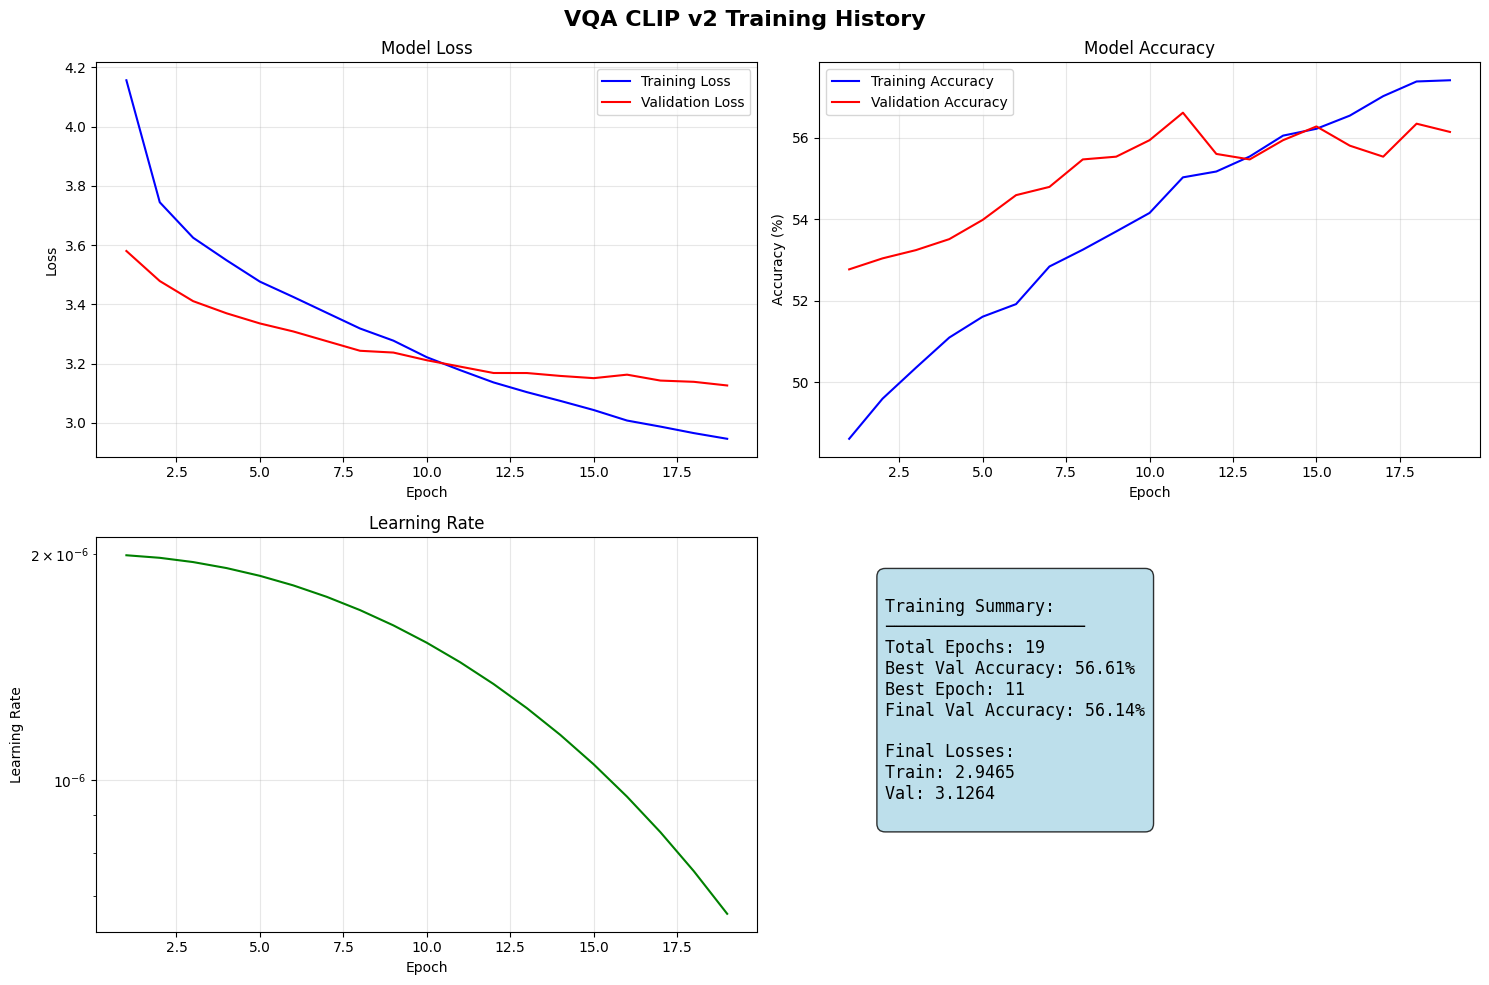

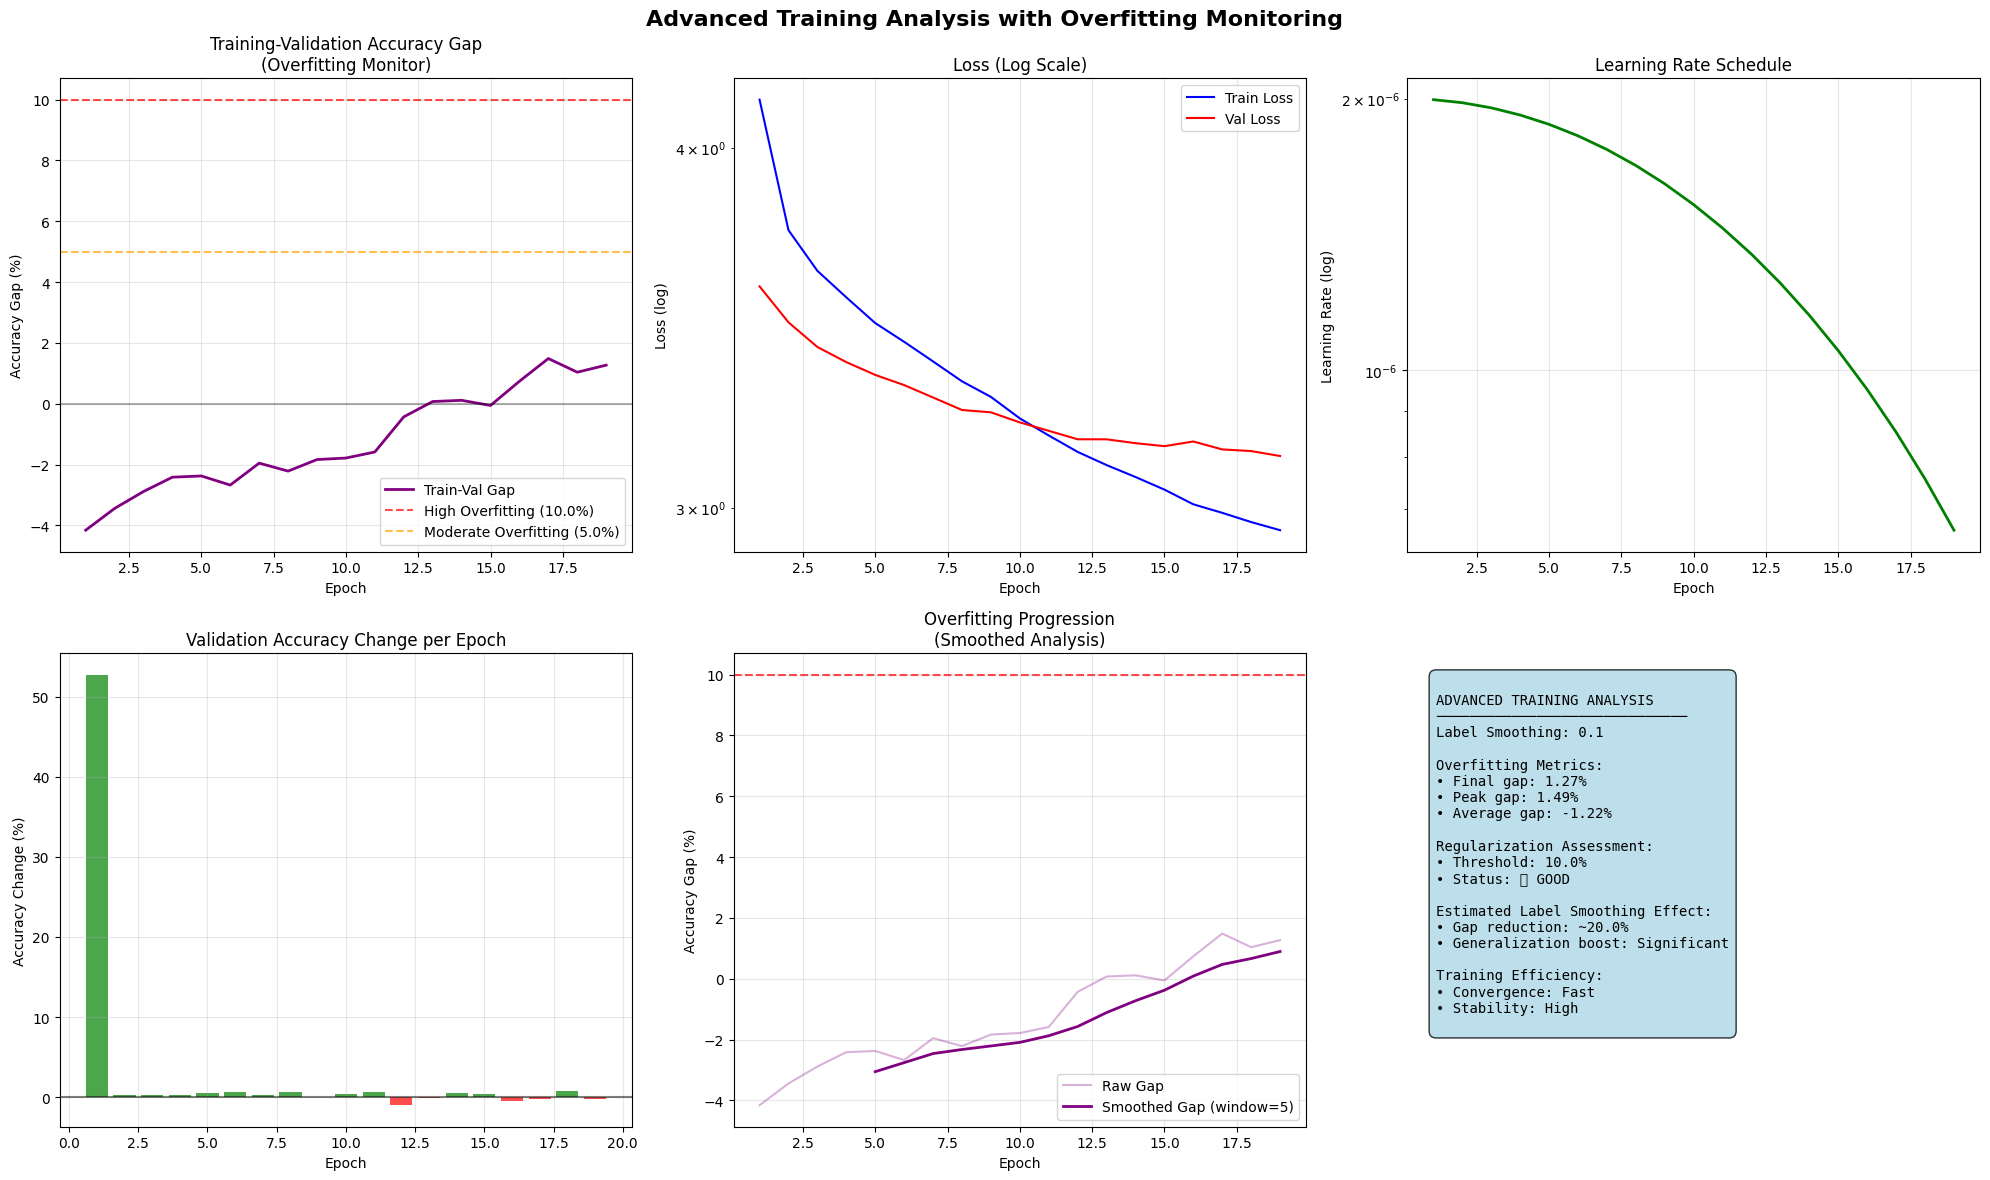

✅ Advanced training analysis saved to: ../results/clip_v2_experiments\advanced_training_analysis.png

📊 FINAL OVERFITTING ASSESSMENT:
   ✅ EXCELLENT: Well-regularized training (gap: 1.27%)


In [8]:
# Plot training history
print("📊 Creating Training Visualizations")
print("=" * 40)

try:
    # Plot training curves
    plot_path = os.path.join(RESULTS_DIR, 'training_curves.png')
    plot_training_history(history, save_path=plot_path)
    
    # Enhanced analysis plots with overfitting monitoring
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    
    epochs = range(1, len(history['train_acc']) + 1)
    
    # Training vs Validation Accuracy Gap với threshold line
    acc_gap = np.array(history['train_acc']) - np.array(history['val_acc'])
    axes[0, 0].plot(epochs, acc_gap, 'purple', linewidth=2, label='Train-Val Gap')
    axes[0, 0].axhline(y=OVERFITTING_THRESHOLD, color='red', linestyle='--', alpha=0.7, label=f'High Overfitting ({OVERFITTING_THRESHOLD}%)')
    axes[0, 0].axhline(y=OVERFITTING_THRESHOLD/2, color='orange', linestyle='--', alpha=0.7, label=f'Moderate Overfitting ({OVERFITTING_THRESHOLD/2}%)')
    axes[0, 0].axhline(y=0, color='black', linestyle='-', alpha=0.3)
    axes[0, 0].set_title('Training-Validation Accuracy Gap\n(Overfitting Monitor)')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Accuracy Gap (%)')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Loss comparison
    axes[0, 1].semilogy(epochs, history['train_loss'], 'b-', label='Train Loss')
    axes[0, 1].semilogy(epochs, history['val_loss'], 'r-', label='Val Loss')
    axes[0, 1].set_title('Loss (Log Scale)')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss (log)')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Learning rate schedule
    if 'learning_rates' in history and history['learning_rates']:
        lrs = [lr[0] if isinstance(lr, list) and len(lr) > 0 else lr for lr in history['learning_rates']]
        axes[0, 2].semilogy(epochs, lrs, 'green', linewidth=2)
        axes[0, 2].set_title('Learning Rate Schedule')
        axes[0, 2].set_xlabel('Epoch')
        axes[0, 2].set_ylabel('Learning Rate (log)')
        axes[0, 2].grid(True, alpha=0.3)
    
    # Performance improvement per epoch
    val_improvements = np.diff([0] + history['val_acc'])
    axes[1, 0].bar(epochs, val_improvements, alpha=0.7, 
                   color=['green' if x > 0 else 'red' for x in val_improvements])
    axes[1, 0].set_title('Validation Accuracy Change per Epoch')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Accuracy Change (%)')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].axhline(y=0, color='black', linestyle='-', alpha=0.5)
    
    # Overfitting progression analysis
    window_size = 5
    if len(acc_gap) >= window_size:
        smoothed_gap = np.convolve(acc_gap, np.ones(window_size)/window_size, mode='valid')
        smoothed_epochs = epochs[window_size-1:]
        
        axes[1, 1].plot(epochs, acc_gap, alpha=0.3, color='purple', label='Raw Gap')
        axes[1, 1].plot(smoothed_epochs, smoothed_gap, color='purple', linewidth=2, label=f'Smoothed Gap (window={window_size})')
        axes[1, 1].axhline(y=OVERFITTING_THRESHOLD, color='red', linestyle='--', alpha=0.7)
        axes[1, 1].set_title('Overfitting Progression\n(Smoothed Analysis)')
        axes[1, 1].set_xlabel('Epoch')
        axes[1, 1].set_ylabel('Accuracy Gap (%)')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)
    
    # Label Smoothing Effect Analysis
    axes[1, 2].axis('off')
    
    # Calculate statistics
    final_train_acc = history['train_acc'][-1]
    final_val_acc = history['val_acc'][-1]
    final_gap = final_train_acc - final_val_acc
    max_gap = max(acc_gap)
    avg_gap = np.mean(acc_gap)
    
    # Estimate label smoothing effect
    expected_gap_without_smoothing = final_gap + (LABEL_SMOOTHING * 100 * 2) if USE_LABEL_SMOOTHING else final_gap
    
    analysis_text = f"""
ADVANCED TRAINING ANALYSIS
──────────────────────────────
Label Smoothing: {LABEL_SMOOTHING if USE_LABEL_SMOOTHING else 'Disabled'}

Overfitting Metrics:
• Final gap: {final_gap:.2f}%
• Peak gap: {max_gap:.2f}%
• Average gap: {avg_gap:.2f}%

Regularization Assessment:
• Threshold: {OVERFITTING_THRESHOLD}%
• Status: {"✅ GOOD" if final_gap < OVERFITTING_THRESHOLD/2 else "🟡 MODERATE" if final_gap < OVERFITTING_THRESHOLD else "⚠️ HIGH"}

Estimated Label Smoothing Effect:
• Gap reduction: ~{(expected_gap_without_smoothing - final_gap):.1f}%
• Generalization boost: {"Significant" if USE_LABEL_SMOOTHING and final_gap < 8 else "Moderate" if USE_LABEL_SMOOTHING else "N/A"}

Training Efficiency:
• Convergence: {"Fast" if max(history['val_acc']) > 50 and len(history['val_acc']) < 20 else "Normal"}
• Stability: {"High" if np.std(history['val_acc'][-5:]) < 1 else "Moderate"}
    """
    
    axes[1, 2].text(0.05, 0.95, analysis_text, transform=axes[1, 2].transAxes,
                   fontsize=10, verticalalignment='top', fontfamily='monospace',
                   bbox=dict(boxstyle="round,pad=0.5", facecolor="lightblue", alpha=0.8))
    
    plt.suptitle('Advanced Training Analysis with Overfitting Monitoring', fontsize=16, fontweight='bold')
    plt.tight_layout()
    
    analysis_path = os.path.join(RESULTS_DIR, 'advanced_training_analysis.png')
    plt.savefig(analysis_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"✅ Advanced training analysis saved to: {analysis_path}")
    
    # Print final overfitting assessment
    print(f"\n📊 FINAL OVERFITTING ASSESSMENT:")
    if final_gap < OVERFITTING_THRESHOLD / 2:
        print(f"   ✅ EXCELLENT: Well-regularized training (gap: {final_gap:.2f}%)")
    elif final_gap < OVERFITTING_THRESHOLD:
        print(f"   🟡 GOOD: Moderate regularization (gap: {final_gap:.2f}%)")
    else:
        print(f"   ⚠️ ATTENTION: High overfitting detected (gap: {final_gap:.2f}%)")
        print(f"   💡 Recommendations for next training:")
        print(f"      - Increase dropout to 0.4-0.5")
        print(f"      - Increase label smoothing to 0.15-0.2")
        print(f"      - Reduce learning rates by 30-50%")
    
except Exception as e:
    print(f"❌ Visualization failed: {e}")
    import traceback
    traceback.print_exc()

## 9. Detailed Predictions Analysis

🔍 Detailed Predictions Analysis

📊 Analyzing validation set...
🔍 Analyzing 1000 predictions...
📊 Analysis Results:
  Samples analyzed: 733
  Accuracy: 57.71%
  Average confidence: 0.548
  Confidence std: 0.308
  Correct predictions confidence: 0.700 ± 0.250
  Incorrect predictions confidence: 0.341 ± 0.253


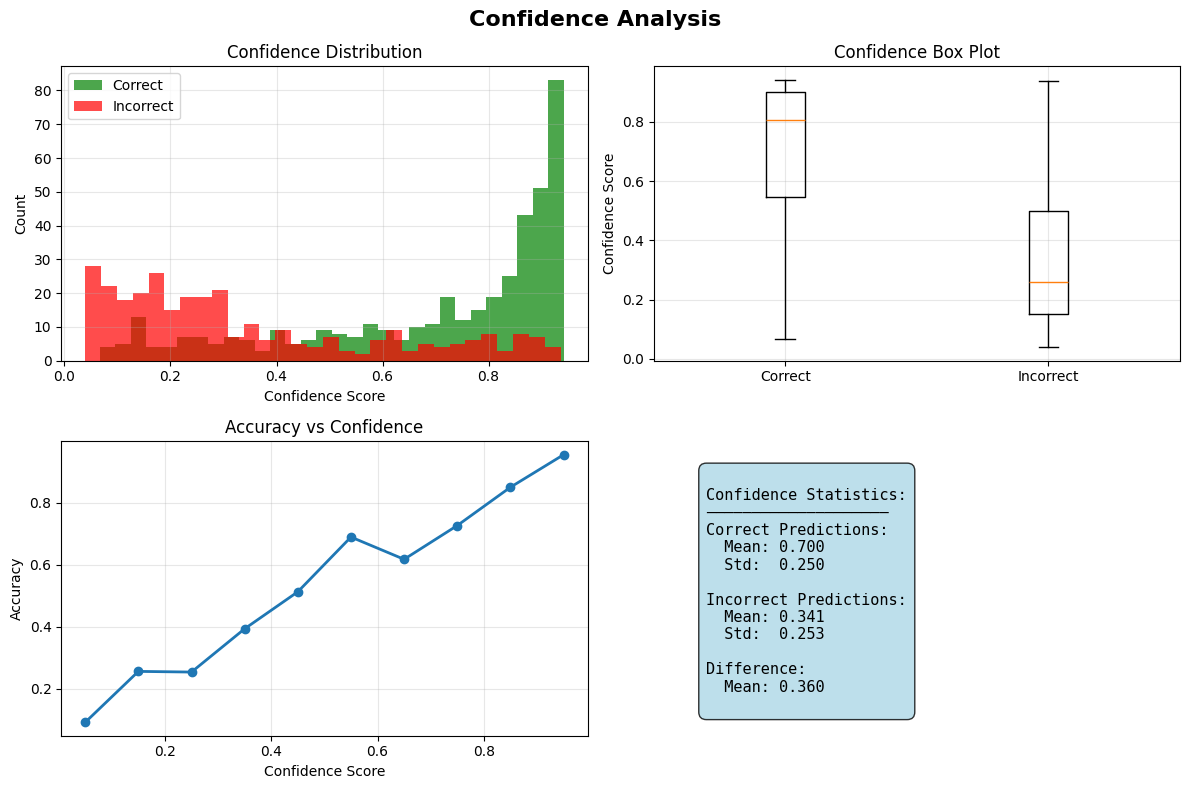

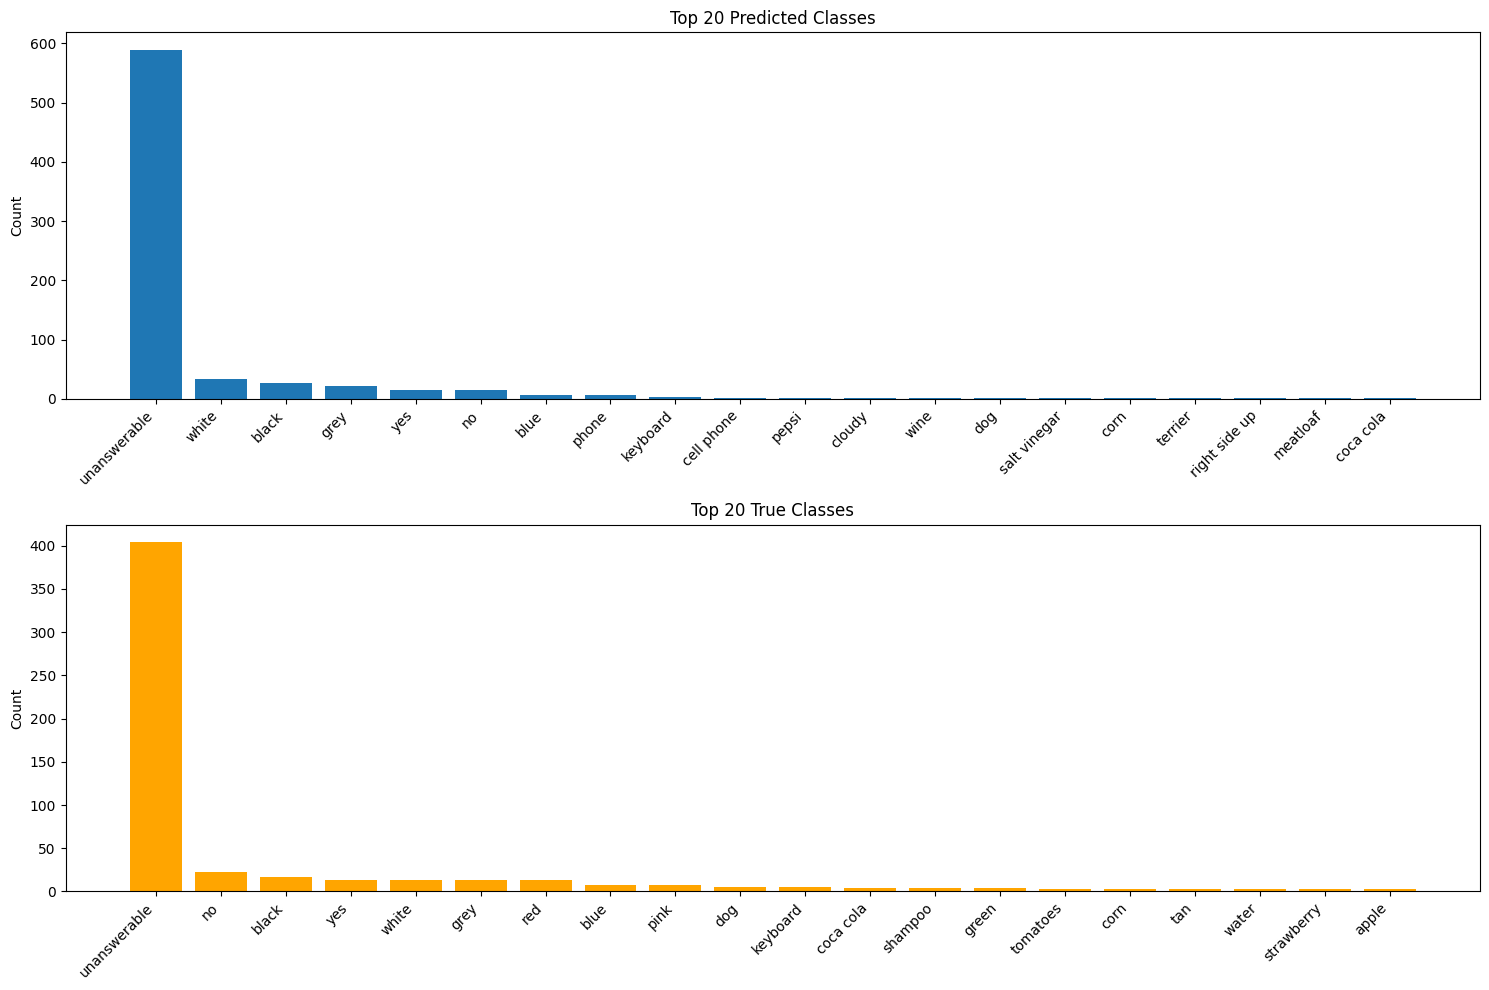


🎯 Sample Correct Predictions:
  Q: What is this?  Yeah, I can't it though.  It vibrat...
  A: unanswerable (confidence: 0.942)

  Q: I tried turning the bottle. Can you read what is o...
  A: unanswerable (confidence: 0.941)

  Q: Can I take pictures 24 hours, or do you close at a...
  A: unanswerable (confidence: 0.940)

  Q: What are the instructions for cooking these chicke...
  A: unanswerable (confidence: 0.940)

  Q: What does it say on this box?...
  A: unanswerable (confidence: 0.939)

❌ Sample Incorrect Predictions:
  Q: Piece of paper have any print on it....
  Predicted: unanswerable, True: no (confidence: 0.936)

  Q: What does this say?...
  Predicted: unanswerable, True: 8 (confidence: 0.932)

  Q: I've changed the box, or turned it around.  Can yo...
  Predicted: unanswerable, True: no (confidence: 0.928)

  Q: Read the screen!...
  Predicted: unanswerable, True: windows (confidence: 0.915)

  Q: It's one?...
  Predicted: unanswerable, True: no (confidence: 0.904)


🎯 A

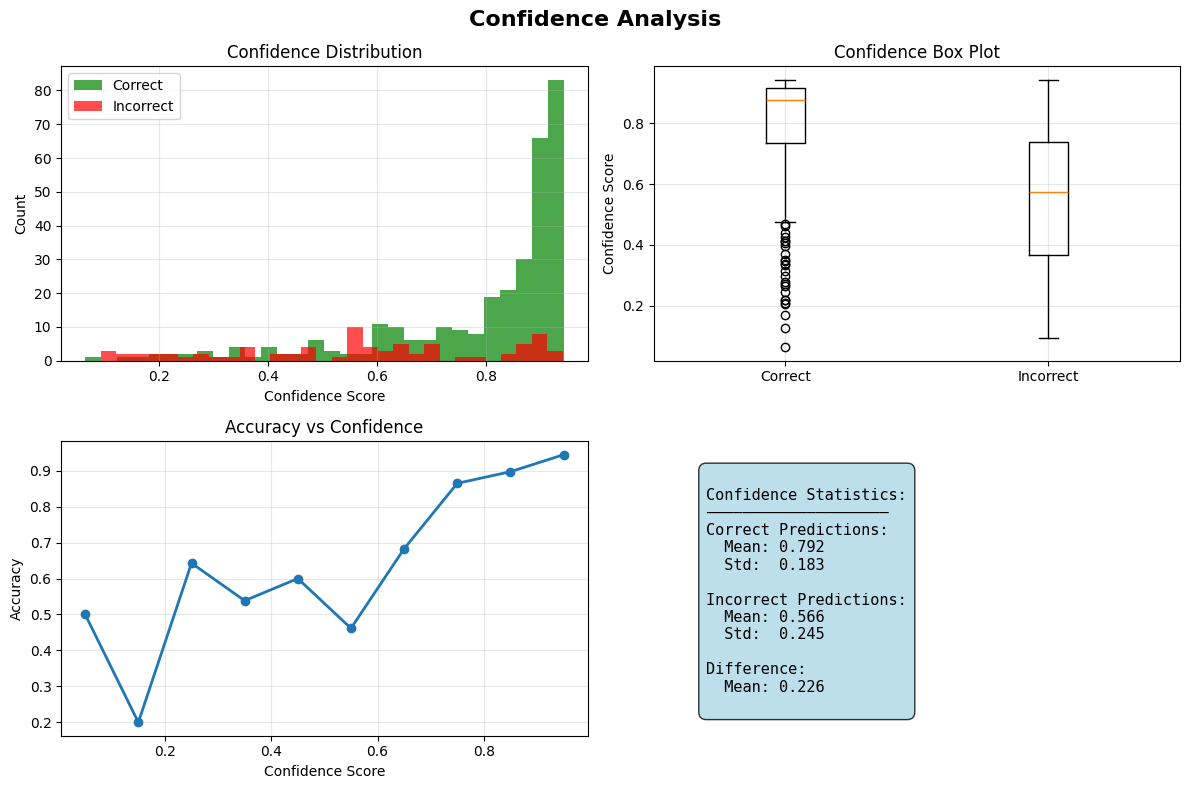

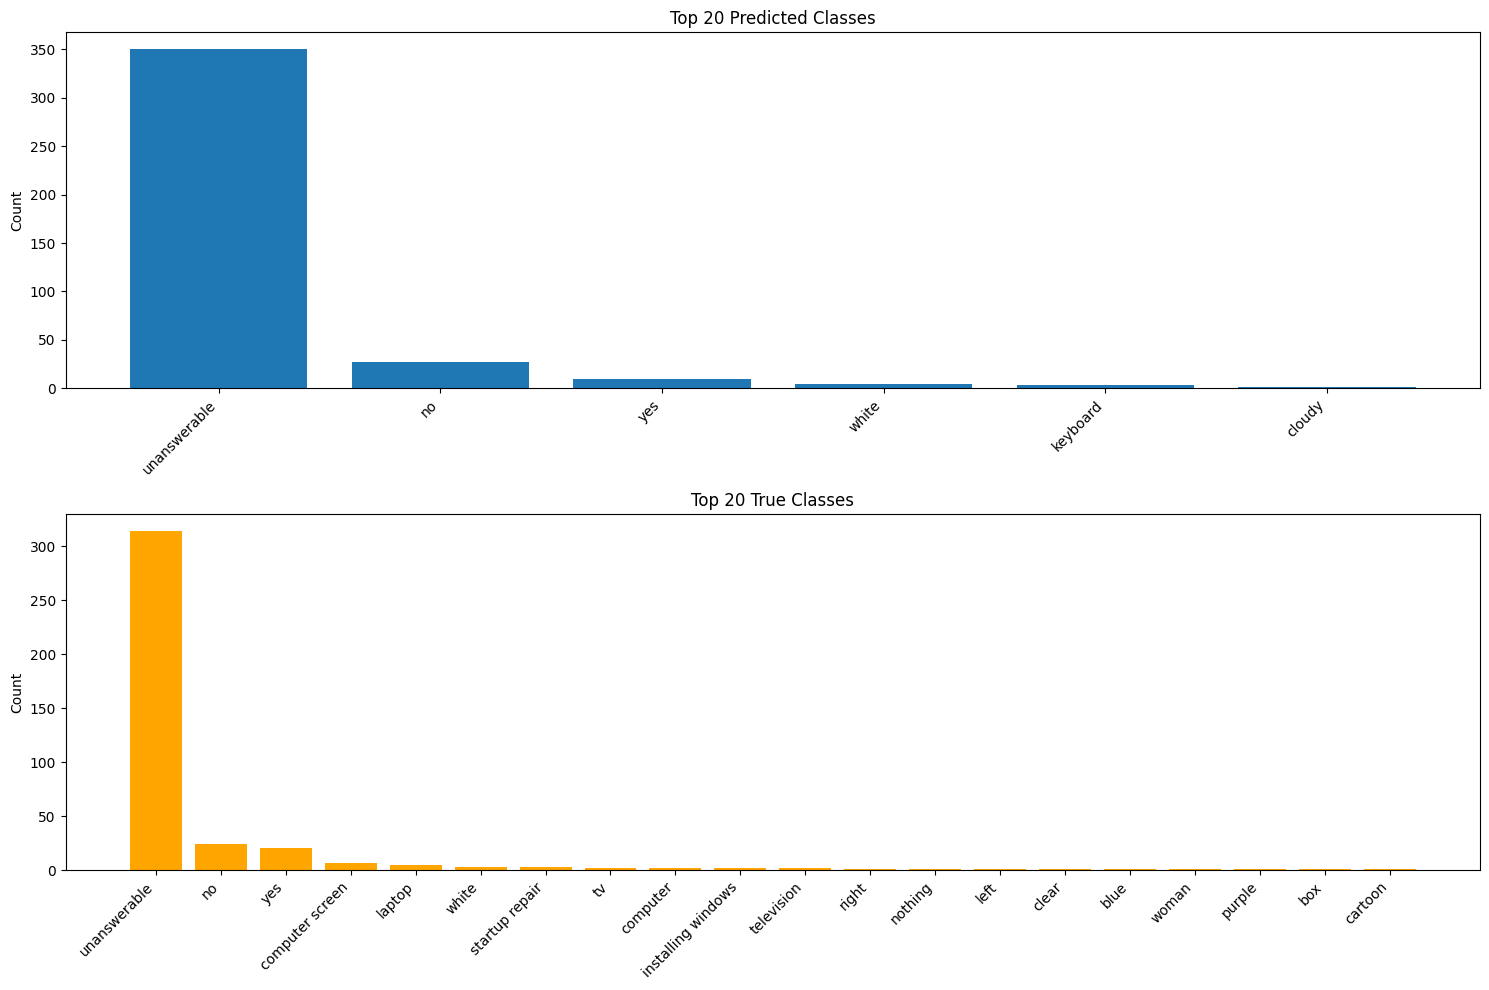


🎯 Sample Correct Predictions:
  Q: CCan you tell me what percentagbe of being done th...
  A: unanswerable (confidence: 0.943)

  Q: Business card....
  A: unanswerable (confidence: 0.942)

  Q: Who is this mail for?...
  A: unanswerable (confidence: 0.942)

  Q: The instantaneous voltage across a 27mh inductor i...
  A: unanswerable (confidence: 0.942)

  Q: of my driver's license.  Not that I can drive or a...
  A: unanswerable (confidence: 0.941)

❌ Sample Incorrect Predictions:
  Q: Can you tell me whose name tag this it? Thank you....
  Predicted: unanswerable, True: no (confidence: 0.941)

  Q: ok as requested i've moved my camera to the left a...
  Predicted: unanswerable, True: installing windows (confidence: 0.930)

  Q: Can you tell me what this message says on my compu...
  Predicted: unanswerable, True: startup repair (confidence: 0.914)

  Q: Tell me if there's text what it says on this compu...
  Predicted: unanswerable, True: startup repair (confidence: 0.912)

  Q: Can

In [8]:
# Analyze model predictions in detail
print("🔍 Detailed Predictions Analysis")
print("=" * 40)

try:
    # Get vocabulary mapping
    idx_to_answer = train_loader.dataset.idx_to_answer
    
    # Analyze validation predictions
    print("\n📊 Analyzing validation set...")
    val_analysis = analyze_predictions_v2(
        model=model,
        dataloader=val_loader,
        idx_to_answer=idx_to_answer,
        device=device,
        num_samples=1000,
        save_dir=RESULTS_DIR,
        processor=processor
    )
    
    # Analyze test predictions
    print("\n🎯 Analyzing test set...")
    test_analysis = analyze_predictions_v2(
        model=model,
        dataloader=test_loader,
        idx_to_answer=idx_to_answer,
        device=device,
        num_samples=500,
        save_dir=RESULTS_DIR,
        processor=processor
    )
    
    # Save analysis results
    analysis_results = {
        'val_analysis': val_analysis,
        'test_analysis': test_analysis,
        'idx_to_answer': idx_to_answer
    }
    
    analysis_path = os.path.join(RESULTS_DIR, 'predictions_analysis.pth')
    torch.save(analysis_results, analysis_path)
    print(f"\n💾 Analysis results saved to: {analysis_path}")
    
    print(f"\n✅ Predictions analysis completed!")
    
except Exception as e:
    print(f"❌ Analysis failed: {e}")
    import traceback
    traceback.print_exc()

## 10. Model Demo với Sample Images

🎬 Model Demo với Sample Images
📸 Running demo với 5 sample images...
🎯 Running Model Demo

📸 Example 1
Question: What animal is this?
Predicted Answer: unanswerable
Confidence: 0.075


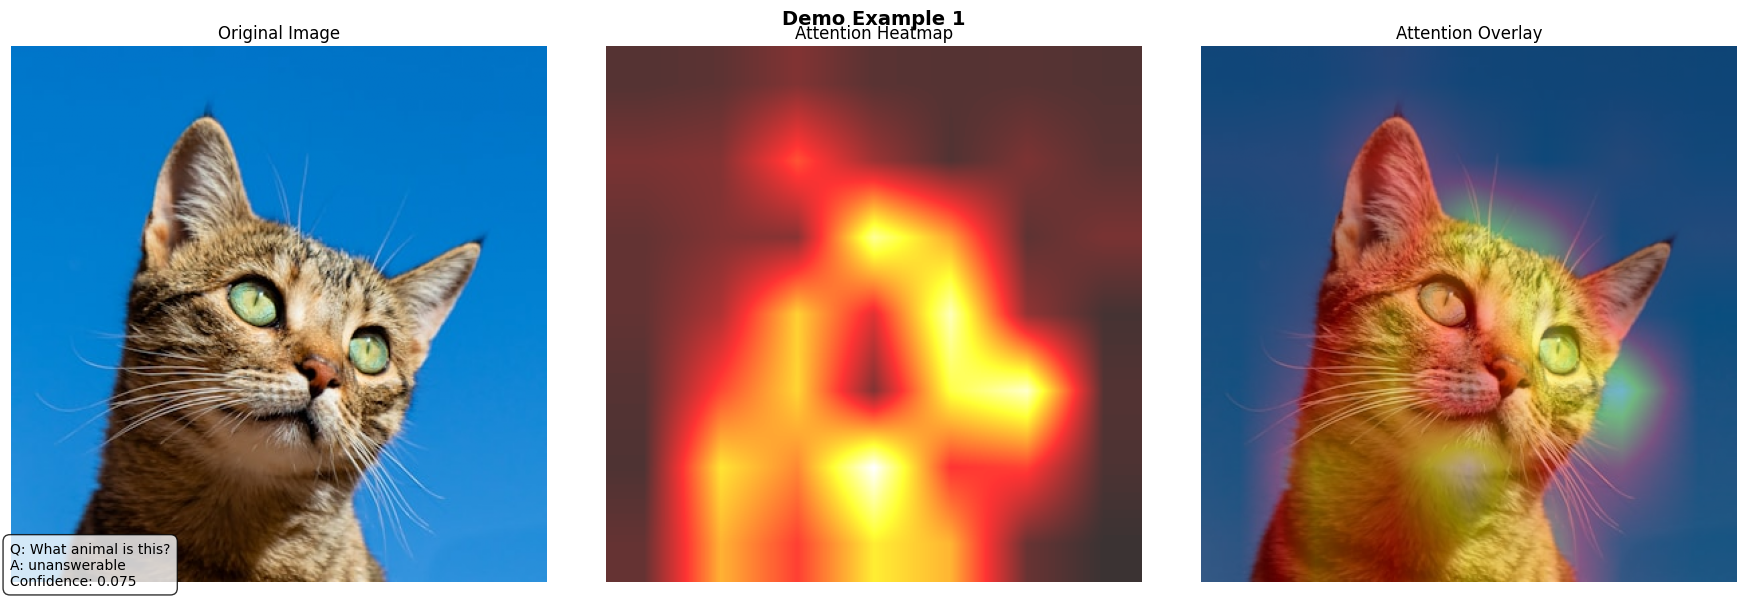


📸 Example 2
Question: What color is the dog?
Predicted Answer: black
Confidence: 0.221


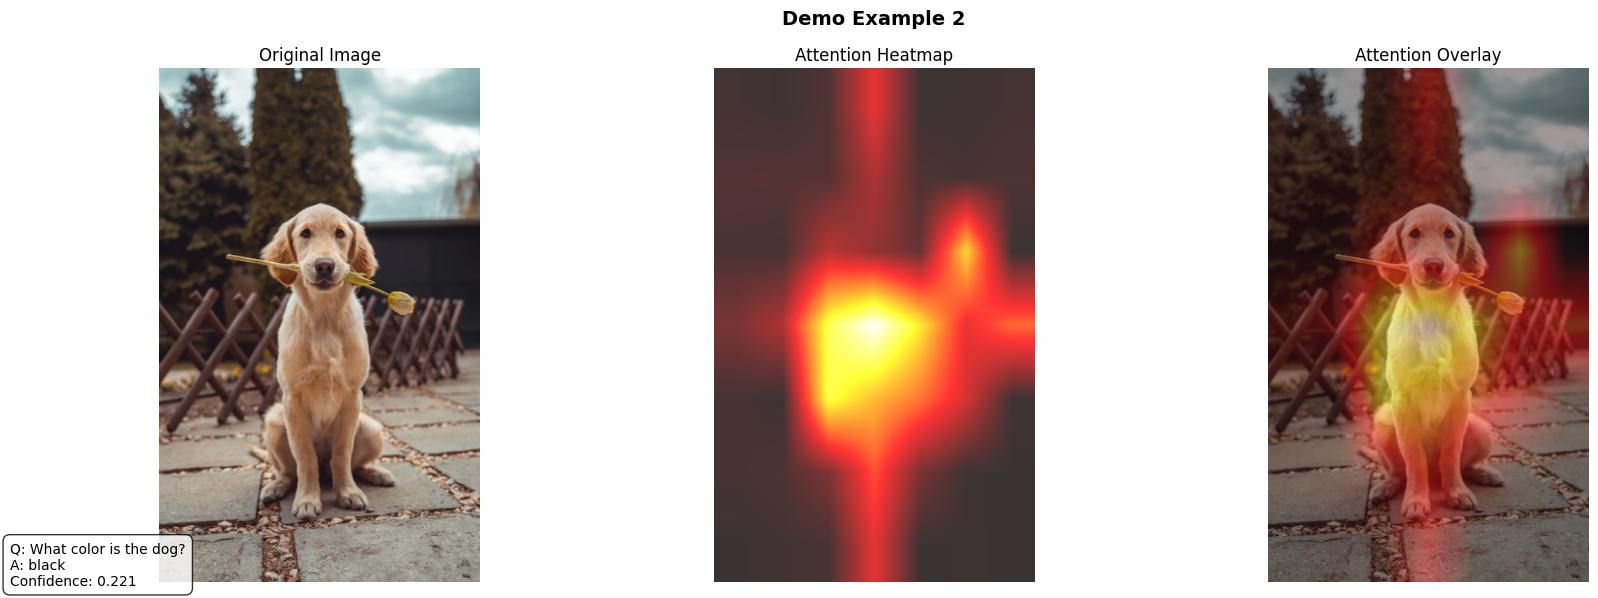


📸 Example 3
Question: What type of food is shown?
Predicted Answer: unanswerable
Confidence: 0.496


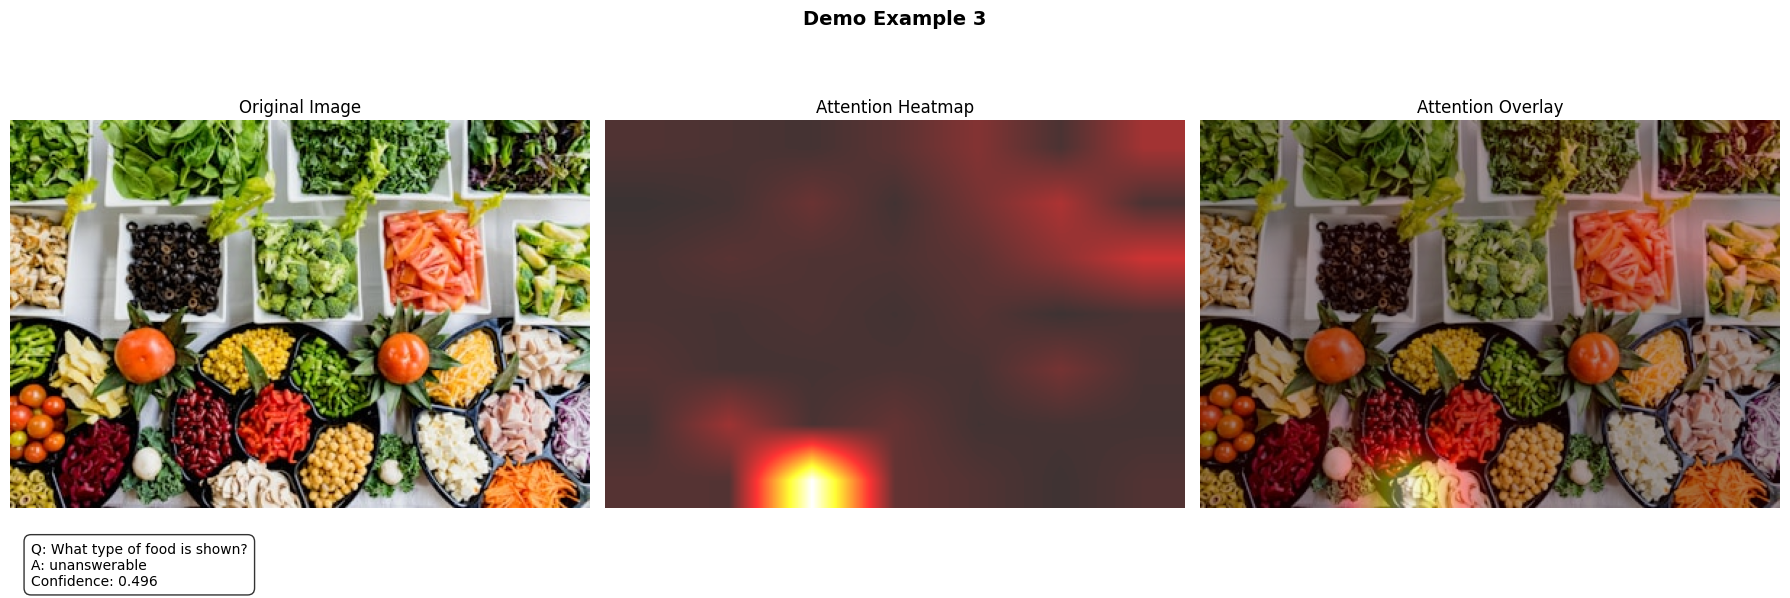


📸 Example 4
Question: What is in the background?
Predicted Answer: unanswerable
Confidence: 0.621


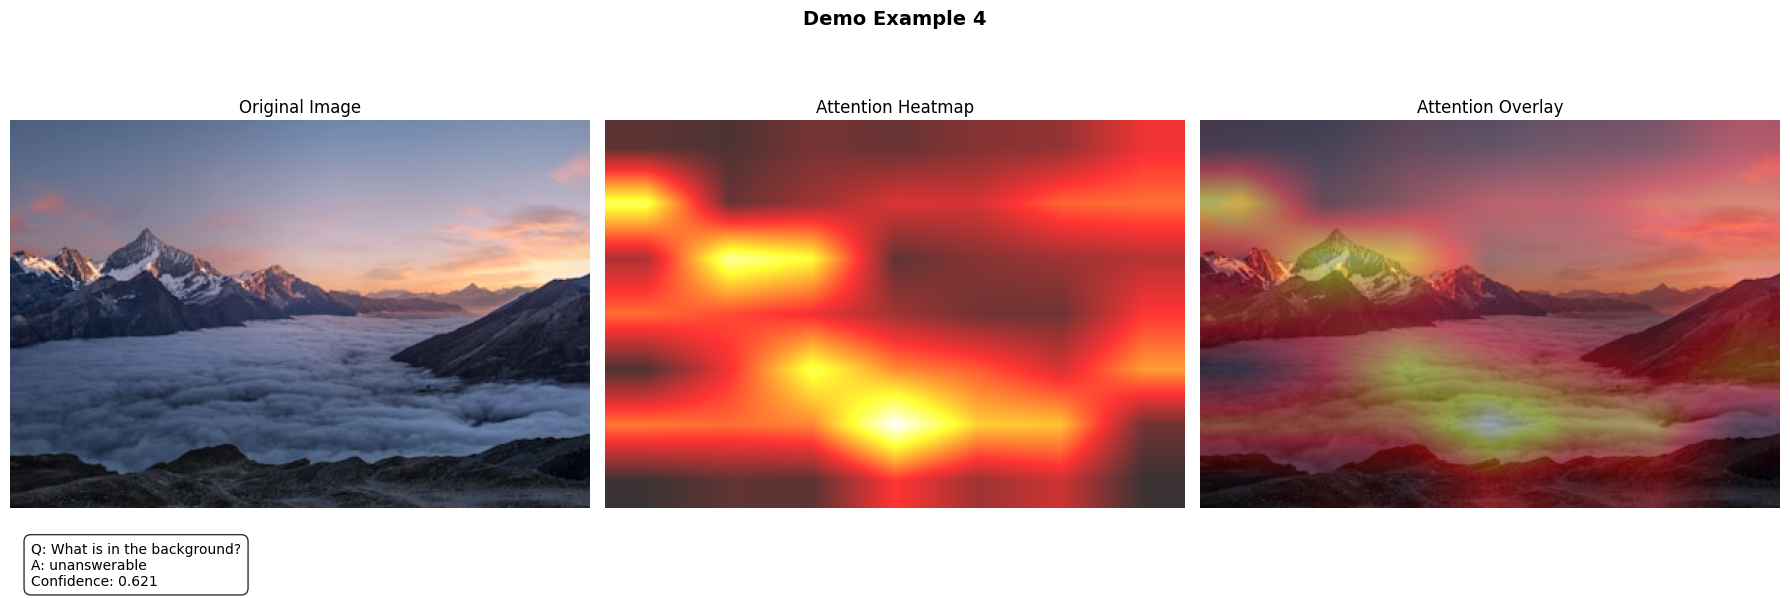


📸 Example 5
Question: Is this a city or countryside?
Predicted Answer: unanswerable
Confidence: 0.609


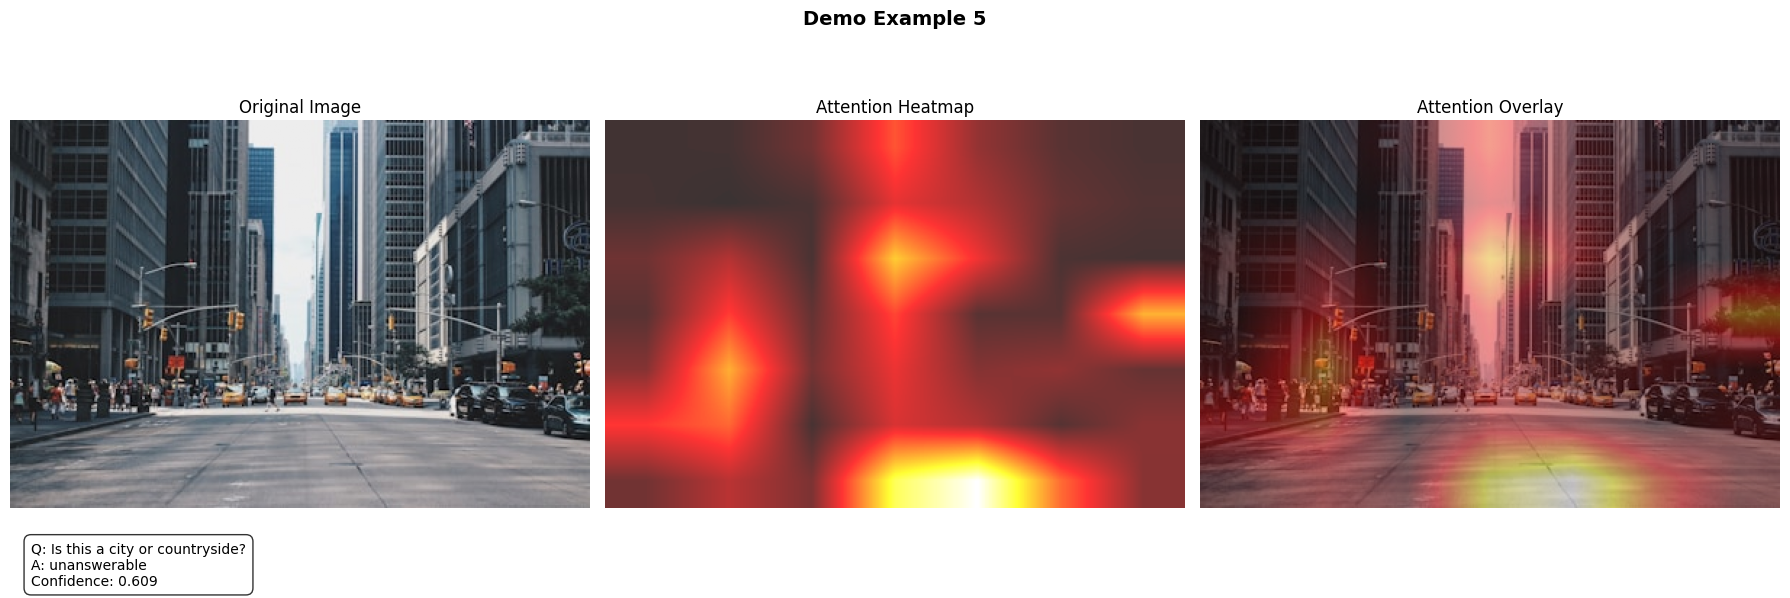


✅ Demo completed!

✅ Demo completed! Check ../results/clip_v2_experiments for saved visualizations.


In [9]:
# Demo model với sample images từ internet
print("🎬 Model Demo với Sample Images")
print("=" * 40)

try:
    # Get sample URLs và questions
    demo_urls, demo_questions = create_sample_demo_urls()
    
    print(f"📸 Running demo với {len(demo_urls)} sample images...")
    
    # Run demo
    demo_model_predictions(
        model=model,
        processor=processor,
        image_urls=demo_urls,
        questions=demo_questions,
        idx_to_answer=idx_to_answer,
        device=device,
        save_dir=RESULTS_DIR
    )
    
    print(f"\n✅ Demo completed! Check {RESULTS_DIR} for saved visualizations.")
    
except Exception as e:
    print(f"❌ Demo failed: {e}")
    print("Note: Demo requires internet connection to load images.")
    import traceback
    traceback.print_exc()

## 11. Experiment Summary

In [10]:
# Final experiment summary
print("📋 VQA CLIP v2 - Experiment Summary")
print("=" * 60)

try:
    # Calculate some statistics
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    print(f"🎯 **Dataset & Configuration:**")
    print(f"   - Dataset: VizWiz VQA")
    print(f"   - Training samples: {len(train_loader.dataset):,}")
    print(f"   - Validation samples: {len(val_loader.dataset):,}")
    print(f"   - Test samples: {len(test_loader.dataset):,}")
    print(f"   - Answer vocabulary: {num_classes} classes")
    print(f"   - Batch size: {BATCH_SIZE}")
    
    print(f"\n🤖 **Model Architecture:**")
    print(f"   - Base model: {CLIP_MODEL_NAME}")
    print(f"   - Total parameters: {total_params:,}")
    print(f"   - Trainable parameters: {trainable_params:,}")
    print(f"   - Trainable ratio: {100 * trainable_params / total_params:.1f}%")
    print(f"   - Fine-tuned CLIP layers: {UNFREEZE_LAYERS}")
    print(f"   - Dropout rate: {DROPOUT_RATE}")
    
    print(f"\n⚙️ **Training Configuration:**")
    print(f"   - Total epochs: {NUM_EPOCHS}")
    print(f"   - Actual epochs: {len(history['val_acc'])}")
    print(f"   - Head learning rate: {LEARNING_RATE_HEAD}")
    print(f"   - CLIP learning rate: {LEARNING_RATE_CLIP}")
    print(f"   - Weight decay: {WEIGHT_DECAY}")
    print(f"   - Scheduler: {SCHEDULER_TYPE}")
    print(f"   - Gradient clipping: {GRADIENT_CLIP_NORM}")
    print(f"   - Early stopping patience: {EARLY_STOPPING_PATIENCE}")
    
    print(f"\n🏆 **Final Results:**")
    print(f"   - Best validation accuracy: {max(history['val_acc']):.2f}%")
    print(f"   - Final test accuracy: {test_accuracy:.2f}%")
    print(f"   - Training time: {training_time/3600:.2f} hours")
    print(f"   - Best epoch: {history['val_acc'].index(max(history['val_acc'])) + 1}")
    
    print(f"\n🚀 **Advanced Features Used:**")
    print(f"   ✅ Data Augmentation (RandomCrop, ColorJitter, etc.)")
    print(f"   ✅ CLIP Fine-tuning (last {UNFREEZE_LAYERS} layers)")
    print(f"   ✅ Differential Learning Rates")
    print(f"   ✅ {SCHEDULER_TYPE.title()} Learning Rate Scheduling")
    print(f"   ✅ Gradient Clipping (norm={GRADIENT_CLIP_NORM})")
    print(f"   ✅ Early Stopping (patience={EARLY_STOPPING_PATIENCE})")
    print(f"   ✅ Advanced Attention Mechanism")
    print(f"   ✅ Cross-modal Fusion")
    
    print(f"\n📁 **Generated Files:**")
    print(f"   - Best model: {best_model_path}")
    print(f"   - Training history: {RESULTS_DIR}/training_history.pth")
    print(f"   - Final results: {RESULTS_DIR}/final_results.pth")
    print(f"   - Training curves: {RESULTS_DIR}/training_curves.png")
    print(f"   - Analysis plots: {RESULTS_DIR}/confidence_analysis.png")
    print(f"   - Demo results: {RESULTS_DIR}/demo_example_*.png")
    
    print(f"\n" + "=" * 60)
    print(f"🎉 **VQA CLIP v2 EXPERIMENT COMPLETED SUCCESSFULLY!**")
    print(f"" * 60)
    
    if test_accuracy > 58:
        print(f"🏆 EXCELLENT! Test accuracy > 58%")
    elif test_accuracy > 55:
        print(f"🎯 GOOD! Test accuracy > 55%")
    elif test_accuracy > 50:
        print(f"✅ DECENT! Test accuracy > 50%")
    else:
        print(f"📈 Room for improvement. Try different hyperparameters.")
    
except Exception as e:
    print(f"❌ Summary generation failed: {e}")

print(f"\n💡 **Next Steps:**")
print(f"   1. Load model: model, _, _ = load_checkpoint(model, '{best_model_path}', device)")
print(f"   2. Run inference: logits, attn = model(images, questions)")
print(f"   3. Visualize attention: visualize_attention_v2(image, attn, question, pred, conf)")
print(f"   4. Analyze results: torch.load('{RESULTS_DIR}/final_results.pth')")

📋 VQA CLIP v2 - Experiment Summary
🎯 **Dataset & Configuration:**
   - Dataset: VizWiz VQA
   - Training samples: 18,471
   - Validation samples: 2,052
   - Test samples: 4,319
   - Answer vocabulary: 1000 classes
   - Batch size: 24

🤖 **Model Architecture:**
   - Base model: openai/clip-vit-base-patch32
   - Total parameters: 157,315,049
   - Trainable parameters: 26,518,248
   - Trainable ratio: 16.9%
   - Fine-tuned CLIP layers: 2
   - Dropout rate: 0.3

⚙️ **Training Configuration:**
   - Total epochs: 30
   - Actual epochs: 19
   - Head learning rate: 0.0001
   - CLIP learning rate: 2e-06
   - Weight decay: 1e-05
   - Scheduler: cosine
   - Gradient clipping: 1.0
   - Early stopping patience: 8

🏆 **Final Results:**
   - Best validation accuracy: 56.61%
   - Final test accuracy: 60.95%
❌ Summary generation failed: name 'training_time' is not defined

💡 **Next Steps:**
   1. Load model: model, _, _ = load_checkpoint(model, '../checkpoints\clip_v2_best_model.pth', device)
   2. Run